In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
mouse = 0
day = 0
session_type = 'OF1'
sorter = 'kilosort4'
storage = Path('/Users/harryclark/Downloads/COHORT12/')

alpha = 0.001
n_jobs = 8
n_shuffles = 100
seed = 1
class Args:
    def __init__(self,mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed):
        self.mouse = mouse
        self.day = day
        self.session_type = session_type
        self.sorter = sorter
        self.storage = storage
        self.alpha = alpha
        self.n_jobs = n_jobs
        self.n_shuffles = n_shuffles
        self.seed = seed
args = Args(mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed)

In [3]:
def load_cluster_locations(clusters, cells):
    for column in ['coord_SCs_x', 'coord_SCs_y', 'coord_SCs_z', 'coord_probe_x', 'coord_probe_y','brain_region']:
        vals = []
        for id in cells.cluster_id:
            vals.append(clusters[column][id])
        cells[column] = vals
    return cells

In [4]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
gcs_and_ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:
        # remove M22 
        if mouse == 22:
            continue
        
        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, percentile_threshold=95, 
                                                                disqualifying_brain_areas_for_spatial_cells=['FL', 'PFL', 'SIM', 'arb', 'root', 'mcp'],
                                                                disqualifying_brain_areas_for_grid_cells=['FL', 'PFL', 'SIM', 'arb', 'root', 'mcp'])
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False, apply_guassian_filter=False)

        gcs = load_cluster_locations(clusters, cells=gcs)
        ngs = load_cluster_locations(clusters, cells=ngs)
        ns = load_cluster_locations(clusters, cells=ns)
        sc = load_cluster_locations(clusters, cells=sc)
        ngs_ns = load_cluster_locations(clusters, cells=ngs_ns)
        all = load_cluster_locations(clusters, cells=all)
        gcs_and_ngs = pd.concat([gcs, ngs], ignore_index=True)


        # run similar analysis for each grid cell to reproduce eLife finding
        for idx, example_cluster_id in enumerate(gcs.cluster_id):
            print(f"\nMouse: {mouse}, Day: {day}, Cluster: {example_cluster_id}")
            last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

            # time binned variables for later
            ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
            speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
            dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
            pos_in_time = dt_in_time%tl
            trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

            if np.any(np.isnan(pos_in_time)):
                series = pd.Series(dt_in_time)
                filled_series = series.ffill().bfill()
                dt_in_time = np.array(filled_series)
                pos_in_time = dt_in_time%tl
                trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

            if np.any(np.isnan(speed_in_time)):
                series = pd.Series(speed_in_time)
                filled_series = series.ffill().bfill()
                speed_in_time = np.array(filled_series)

            # compute the spectrogram and labels from the most adunant grid module
            peak_indices = [12, 28, 44, 60, 76]
            tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in [example_cluster_id] if cluster_id in tcs}
            tcs_to_use[1000] = tcs_to_use[example_cluster_id]

            # HACK add a little noise for cases where there is long periods of no firing
            tcs_to_use[1000] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)
            tcs_to_use[example_cluster_id] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)

            # note: labelling won't work for cells with very spikes
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            spectrograms = results[3] 
            fvalid = results[5]
            S = spectrograms.mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels = np.isin(max_peaks, peak_indices).astype(int)

            # compute trial labels for task anchoring to use
            tc = tcs[example_cluster_id] # example grid cell
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin] # only want bins with ephys data in it
            task_anchored_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

            # compute percentage hits among labelled trials for non-beaconed and beaconed trials
            last_trial = int(last_ephys_bin/(tl/bs))
            trial_types = beh['trials'].type[:last_trial].values
            trial_performances = beh['trials'].performance[:last_trial].values

            def percentage_hits(trial_type, task_label):
                mask = (trial_types == trial_type) & (task_anchored_labels == task_label)
                hits = np.sum(trial_performances[mask] == 'hit')
                total = np.sum(mask)
                return 100 * hits / total if total > 0 else np.nan

            pct_b_1 = percentage_hits('b', 1)
            pct_nb_1 = percentage_hits('nb', 1)
            pct_b_0 = percentage_hits('b', 0)
            pct_nb_0 = percentage_hits('nb', 0)

            # Store in gcs dataframe for this cell
            gcs.loc[gcs.index[idx], 'pct_b_1'] = pct_b_1
            gcs.loc[gcs.index[idx], 'pct_nb_1'] = pct_nb_1
            gcs.loc[gcs.index[idx], 'pct_b_0'] = pct_b_0
            gcs.loc[gcs.index[idx], 'pct_nb_0'] = pct_nb_0

            print(f"Percentage hits for type='b', task_anchored_label=1: {pct_b_1:.2f}%")
            print(f"Percentage hits for type='nb', task_anchored_label=1: {pct_nb_1:.2f}%")
            print(f"Percentage hits for type='b', task_anchored_label=0: {pct_b_0:.2f}%")
            print(f"Percentage hits for type='nb', task_anchored_label=0: {pct_nb_0:.2f}%")

        
        # run analysis for each non-grid cell
        for idx, example_cluster_id in enumerate(ngs.cluster_id):
            print(f"\nMouse: {mouse}, Day: {day}, Cluster: {example_cluster_id}")
            last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

            # time binned variables for later
            ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
            speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
            dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
            pos_in_time = dt_in_time%tl
            trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

            if np.any(np.isnan(pos_in_time)):
                series = pd.Series(dt_in_time)
                filled_series = series.ffill().bfill()
                dt_in_time = np.array(filled_series)
                pos_in_time = dt_in_time%tl
                trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

            if np.any(np.isnan(speed_in_time)):
                series = pd.Series(speed_in_time)
                filled_series = series.ffill().bfill()
                speed_in_time = np.array(filled_series)

            # compute the spectrogram and labels from the most adunant grid module
            peak_indices = [12, 28, 44, 60, 76]
            tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in [example_cluster_id] if cluster_id in tcs}
            tcs_to_use[1000] = tcs_to_use[example_cluster_id]

            # HACK add a little noise for cases where there is long periods of no firing
            tcs_to_use[1000] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)
            tcs_to_use[example_cluster_id] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)

            # note: labelling won't work for cells with very spikes
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            spectrograms = results[3] 
            fvalid = results[5]
            S = spectrograms.mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels = np.isin(max_peaks, peak_indices).astype(int)
            
            # compute trial labels for task anchoring to use
            tc = tcs[example_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            task_anchored_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl)

            last_trial = int(last_ephys_bin/(tl/bs))
            trial_types = beh['trials'].type[:last_trial].values
            trial_performances = beh['trials'].performance[:last_trial].values

            def percentage_hits(trial_type, task_label):
                mask = (trial_types == trial_type) & (task_anchored_labels == task_label)
                hits = np.sum(trial_performances[mask] == 'hit')
                total = np.sum(mask)
                return 100 * hits / total if total > 0 else np.nan

            ngs.loc[ngs.index[idx], 'pct_b_1'] = percentage_hits('b', 1)
            ngs.loc[ngs.index[idx], 'pct_nb_1'] = percentage_hits('nb', 1)
            ngs.loc[ngs.index[idx], 'pct_b_0'] = percentage_hits('b', 0)
            ngs.loc[ngs.index[idx], 'pct_nb_0'] = percentage_hits('nb', 0)

        # bring everything back
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        ns_ = pd.concat([ns_, ns], ignore_index=True)
        sc_ = pd.concat([sc_, sc], ignore_index=True)
        ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
        all_ = pd.concat([all_, all], ignore_index=True)

print(f'there are this many cells at the moment, {len(all_)}')
print(f'there are this many gcs at the moment, {len(gcs_)}')
print(f'there are this many ngs at the moment, {len(ngs_)}')
print(f'there are this many ns at the moment, {len(ns_)}')

optimal travel lag is 1.8518518518518547 cm based on kde of travel at max spatial information
using travel lag of 1.8518518518518547 cm
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1


Beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  917     Method:             ML        
No. Groups:        7       Scale:              94.2375   
Min. group size:   72      Log-Likelihood:     -3473.3817
Max. group size:   220     Converged:          No        
Mean group size:   131.0                                 
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      78.274    1.934 40.472 0.000 74.484 82.065
C(label)[T.1]   2.853    0.644  4.432 0.000  1.592  4.115
cluster Var     0.227    1.502                           
day Var       191.386    3.211                           


Non-beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  960   

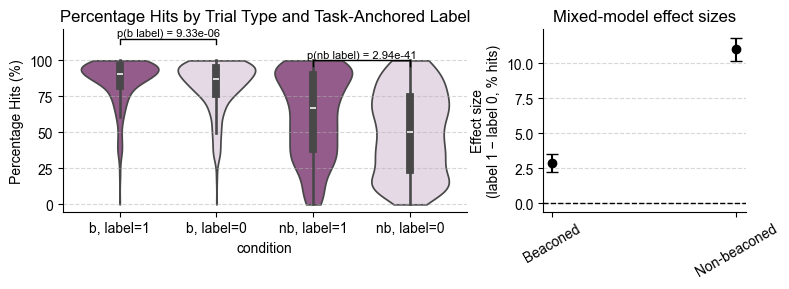

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Build long-form DataFrame for seaborn and mixed models
# We want order: b, label=1; b, label=0; nb, label=1; nb, label=0
records = []
for _, row in gcs_.iterrows():
    for trial_type in ['b', 'nb']:
        for label in [0, 1]:
            col = f'pct_{trial_type}_{label}'
            if col not in row or pd.isna(row[col]):
                continue
            records.append({
                'pct_hits': row[col],
                'trial_type': trial_type,
                'label': label,
                'condition': f'{trial_type}, label={label}',
                'mouse': row.get('mouse', np.nan),
                'day': row.get('day', np.nan),
                'cluster_id': row.get('cluster_id', np.nan),
            })

df_plot = pd.DataFrame.from_records(records)

# Ensure categorical ordering: b,label=1; b,label=0; nb,label=1; nb,label=0
order = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

# Color mapping: label 0 -> #e7d7e8, label 1 -> #9d5391
palette = {
    'b, label=0':  '#e7d7e8',
    'b, label=1':  '#9d5391',
    'nb, label=0': '#e7d7e8',
    'nb, label=1': '#9d5391',
}

# ----- Mixed models for comparisons within beaconed and non-beaconed -----
p_b = np.nan
p_nb = np.nan
eff_b = np.nan     # effect size (label 1 − label 0) from LMM for beaconed
eff_nb = np.nan    # effect size for non-beaconed
se_b = np.nan      # standard error of effect
se_nb = np.nan

def fit_lmm_trialtype(df_subset, trial_label):
    """
    Fit LMM: pct_hits ~ C(label) for a given trial type ('b' or 'nb').

    Returns:
        pval, effect, se
        where effect is the fixed-effect estimate for label 1 vs 0,
        and se is its standard error.
    """
    df_mod = df_subset.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        print(f"{trial_label}: not enough data for both labels")
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label)',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={
                'day': '0 + C(day)',
                'cluster': '0 + C(cluster_id)',
            },
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{trial_label}: mixed model summary")
        print(m_fit.summary())

        term = 'C(label)[T.1]'
        pval = m_fit.pvalues.get(term, np.nan)
        effect = m_fit.params.get(term, np.nan)

        cov = m_fit.cov_params()
        if term in cov.index:
            se = np.sqrt(cov.loc[term, term])
        else:
            se = np.nan

        return pval, effect, se
    except Exception as e:
        print(f"\n{trial_label}: mixed model failed with error: {e}")
        return np.nan, np.nan, np.nan

# Beaconed only
df_b = df_plot[df_plot['trial_type'] == 'b']
p_b, eff_b, se_b = fit_lmm_trialtype(df_b, 'Beaconed')

# Non-beaconed only
df_nb = df_plot[df_plot['trial_type'] == 'nb']
p_nb, eff_nb, se_nb = fit_lmm_trialtype(df_nb, 'Non-beaconed')

# ----- Figure with two subplots: violin + effect sizes -----
fig, axes = plt.subplots(1, 2, figsize=(8, 3), gridspec_kw={'width_ratios': [2, 1]})

# Left: seaborn violin with annotations
ax = axes[0]
sns.violinplot(
    data=df_plot,
    x='condition',
    y='pct_hits',
    order=order,
    palette=palette,
    inner='box',   # show median and IQR inside violins
    cut=0,
    ax=ax,
)

ax.set_ylabel('Percentage Hits (%)')
ax.set_title('Percentage Hits by Trial Type and Task-Anchored Label')
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax)

# Annotate LMM comparisons with brackets:
#  - Beaconed: between x=0 (b,1) and x=1 (b,0)
#  - Non-beaconed: between x=2 (nb,1) and x=3 (nb,0)

# Expand y-limits to create headroom for annotations above the violins
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin
ymax_new = ymax + 0.15 * yrange  # add 15% headroom
ax.set_ylim(ymin, ymax_new)
yrange = ymax_new - ymin  # recompute

# Beaconed bracket (above the two left violins)
x1_b, x2_b = 0, 1
bracket_y_b = ymax_new - 0.08 * yrange
h_b = 0.03 * yrange
ax.plot(
    [x1_b, x1_b, x2_b, x2_b],
    [bracket_y_b, bracket_y_b + h_b, bracket_y_b + h_b, bracket_y_b],
    color='k',
    linewidth=1.0,
)
ax.text(
    (x1_b + x2_b) / 2,
    bracket_y_b + h_b * 1.05,
    f"p(b label) = {p_b:.3g}" if not np.isnan(p_b) else "p(b label) = NA",
    ha='center',
    va='bottom',
    fontsize=8,
)

# Non-beaconed bracket (above the two right violins)
x1_nb, x2_nb = 2, 3
bracket_y_nb = ymax_new - 0.20 * yrange
h_nb = 0.03 * yrange
ax.plot(
    [x1_nb, x1_nb, x2_nb, x2_nb],
    [bracket_y_nb, bracket_y_nb + h_nb, bracket_y_nb + h_nb, bracket_y_nb],
    color='k',
    linewidth=1.0,
)
ax.text(
    (x1_nb + x2_nb) / 2,
    bracket_y_nb + h_nb * 1.05,
    f"p(nb label) = {p_nb:.3g}" if not np.isnan(p_nb) else "p(nb label) = NA",
    ha='center',
    va='bottom',
    fontsize=8,
)

# Right: effect size plot (label 1 − label 0) from the mixed models
ax_eff = axes[1]

x_eff = np.array([0, 1])
y_eff = np.array([eff_b, eff_nb])
y_err = np.array([se_b, se_nb])

# Mask out NaNs so matplotlib doesn't complain
mask = ~np.isnan(y_eff)
ax_eff.errorbar(
    x_eff[mask],
    y_eff[mask],
    yerr=y_err[mask] if not np.all(np.isnan(y_err[mask])) else None,
    fmt='o',
    color='k',
    capsize=4,
)
ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)

ax_eff.set_xticks([0, 1])
ax_eff.set_xticklabels(['Beaconed', 'Non-beaconed'], rotation=30)
ax_eff.set_ylabel('Effect size\n(label 1 − label 0, % hits)')
ax_eff.set_title('Mixed-model effect sizes')

ax_eff.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_eff)

plt.tight_layout()
plt.show()

GCS (nb): Medial cells = 336, Lateral cells = 129

GCS (nb): mixed model summary
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   delta_pct 
No. Observations:   465       Method:               ML        
No. Groups:         7         Scale:                321.5239  
Min. group size:    35        Log-Likelihood:       -2039.1234
Max. group size:    116       Converged:            Yes       
Mean group size:    66.4                                      
--------------------------------------------------------------
                     Coef.  Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept             7.720    2.470 3.126 0.002  2.879 12.560
C(region)[T.medial]   2.951    2.701 1.093 0.275 -2.342  8.244
cluster Var           0.032    2.676                          
day Var             148.635    2.735                          

GCS (nb) - lateral: Δ vs 0 from LMM, z = 3.13, p 

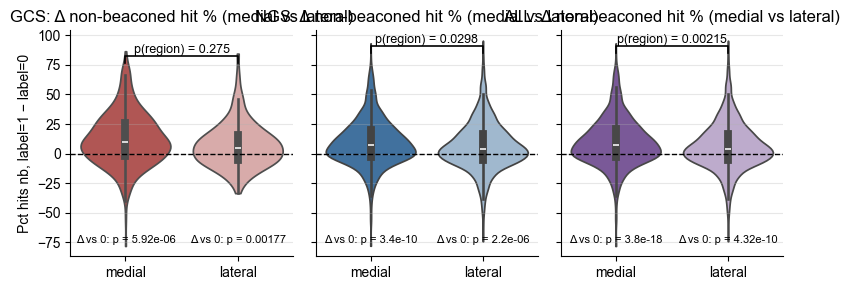

GCS (b): Medial cells = 316, Lateral cells = 127

GCS (b): mixed model summary
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  delta_pct 
No. Observations:    443      Method:              ML        
No. Groups:          7        Scale:               179.0708  
Min. group size:     36       Log-Likelihood:      -1830.7758
Max. group size:     108      Converged:           Yes       
Mean group size:     63.3                                    
-------------------------------------------------------------
                    Coef.  Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept            2.376    1.875 1.267 0.205 -1.300  6.052
C(region)[T.medial]  2.159    2.114 1.021 0.307 -1.984  6.302
cluster Var         17.651    2.458                          
day Var             75.844    1.921                          

GCS (b) - lateral: Δ vs 0 from LMM, z = 1.27, p = 0.205
GCS (b) 

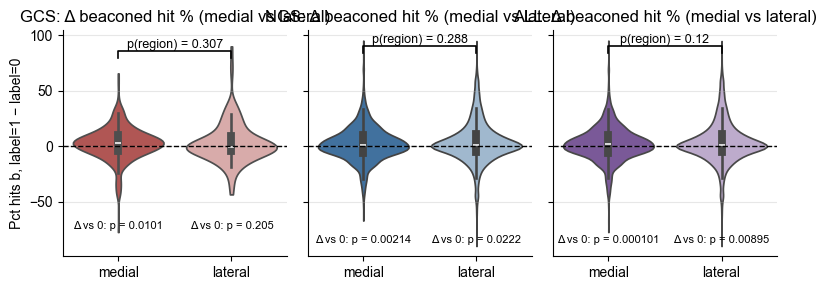

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.colors as mcolors


def lighten_color(color, factor=0.5):
    """
    Lighten the given color by mixing it with white.
    factor in (0, 1): smaller = closer to original, larger = lighter.
    """
    rgb = np.array(mcolors.to_rgb(color))
    return mcolors.to_hex((1 - factor) * rgb + factor * np.ones_like(rgb))


def analyze_group(name, base_df, medial_color, ax, trial_type="nb"):
    """
    name: 'GCS', 'NGS', or 'ALL'
    base_df: DataFrame with pct_* and coord_SCs_x, mouse, day, cluster_id
    medial_color: color for medial cells (string, e.g. '#c04744')
    ax: matplotlib Axes to plot into
    trial_type: 'nb' (non-beaconed) or 'b' (beaconed)
    """
    # Choose columns for the requested trial type
    col_1 = f"pct_{trial_type}_1"
    col_0 = f"pct_{trial_type}_0"

    # Compute difference in hit percentage between label=1 and label=0
    delta_pct = base_df[col_1] - base_df[col_0]

    # Use SC x-coordinate and create a flipped version so medial < 3400
    sc_x = base_df["coord_SCs_x"]
    sc_x_flipped = -sc_x  # do NOT write back into base_df, so we don't double-flip

    # Keep only rows with valid values
    valid_mask = ~delta_pct.isna() & ~sc_x_flipped.isna()

    # Build modelling DataFrame (copy so we don't mutate base_df)
    df = base_df.copy()
    df["delta_pct"] = delta_pct
    df["coord_SCs_x_flipped"] = sc_x_flipped
    df = df[valid_mask]

    # Define medial vs lateral based on 3400 µm cutoff
    df["region"] = np.where(df["coord_SCs_x_flipped"] < 3400, "medial", "lateral")

    n_medial = (df["region"] == "medial").sum()
    n_lateral = (df["region"] == "lateral").sum()
    print(f"{name} ({trial_type}): Medial cells = {n_medial}, Lateral cells = {n_lateral}")

    # ----- Linear mixed-effects model: Δ ~ region with mouse/day/cluster hierarchy -----
    try:
        md = smf.mixedlm(
            "delta_pct ~ C(region)",
            df,
            groups=df["mouse"],
            vc_formula={
                "day": "0 + C(day)",
                "cluster": "0 + C(cluster_id)",
            },
        )
        m_fit = md.fit(reml=False, method="lbfgs")
        print(f"\n{name} ({trial_type}): mixed model summary")
        print(m_fit.summary())

        # Identify the region contrast term (e.g. C(region)[T.medial])
        region_terms = [pname for pname in m_fit.params.index if pname.startswith("C(region)")]
        region_term = region_terms[0] if len(region_terms) > 0 else None

        # p-value for medial vs lateral contrast
        pval_region = m_fit.pvalues.get(region_term, np.nan) if region_term is not None else np.nan

        # ----- Δ vs 0 tests derived from fixed effects (intercept + region contrast) -----
        # Lateral (reference) mean: intercept
        params = m_fit.params
        cov = m_fit.cov_params()

        beta0 = params["Intercept"]
        var0 = cov.loc["Intercept", "Intercept"]
        z_lat = beta0 / np.sqrt(var0)
        p_zero_lat = 2 * stats.norm.sf(np.abs(z_lat))

        # Medial mean: intercept + region contrast
        if region_term is not None:
            beta_region = params[region_term]
            var_region = cov.loc[region_term, region_term]
            cov01 = cov.loc["Intercept", region_term]
            beta_med = beta0 + beta_region
            var_med = var0 + var_region + 2 * cov01
            z_med = beta_med / np.sqrt(var_med)
            p_zero_med = 2 * stats.norm.sf(np.abs(z_med))
        else:
            p_zero_med = np.nan

        print(f"{name} ({trial_type}) - lateral: Δ vs 0 from LMM, z = {z_lat:.3g}, p = {p_zero_lat:.3g}")
        if not np.isnan(p_zero_med):
            print(f"{name} ({trial_type}) - medial: Δ vs 0 from LMM, z = {z_med:.3g}, p = {p_zero_med:.3g}")
        else:
            print(
                f"{name} ({trial_type}) - medial: Δ vs 0 from LMM could not be computed "
                "(no region contrast term)"
            )
    except Exception as e:
        print(f"\n{name} ({trial_type}): mixed model failed with error: {e}")
        pval_region = np.nan
        p_zero_med = np.nan
        p_zero_lat = np.nan

    # ----- Seaborn violin plot into the provided axis -----
    lateral_color = lighten_color(medial_color, factor=0.5)

    sns.violinplot(
        data=df,
        x="region",
        y="delta_pct",
        order=["medial", "lateral"],
        palette={
            "medial": medial_color,
            "lateral": lateral_color,
        },
        inner="box",  # shows median and IQR inside the violins
        cut=0,
        ax=ax,
    )

    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel("")  # regions already on x-axis

    trial_label = "non-beaconed" if trial_type == "nb" else "beaconed"
    ax.set_ylabel(f"Pct hits {trial_type}, label=1 − label=0")
    ax.set_title(f"{name}: Δ {trial_label} hit % (medial vs lateral)")

    # Get y-range for positioning annotations
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin

    # ----- Comparative p-value on a bracket between medial and lateral -----
    x1, x2 = 0, 1
    bracket_y = ymax - 0.1 * yrange
    h = 0.03 * yrange

    ax.plot(
        [x1, x1, x2, x2],
        [bracket_y, bracket_y + h, bracket_y + h, bracket_y],
        color="k",
        linewidth=1.2,
    )
    ax.text(
        (x1 + x2) / 2,
        bracket_y + h * 1.1,
        f"p(region) = {pval_region:.3g}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

    # ----- Per-region Δ vs 0 p-values below each distribution (from mixed model) -----
    text_y = ymin + 0.05 * yrange

    if not np.isnan(p_zero_med):
        med_text = f"Δ vs 0: p = {p_zero_med:.3g}"
    else:
        med_text = "Δ vs 0: n<2 or model fail"
    ax.text(
        0,
        text_y,
        med_text,
        ha="center",
        va="bottom",
        fontsize=8,
    )

    if not np.isnan(p_zero_lat):
        lat_text = f"Δ vs 0: p = {p_zero_lat:.3g}"
    else:
        lat_text = "Δ vs 0: n<2 or model fail"
    ax.text(
        1,
        text_y,
        lat_text,
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

    print("\n" + "-" * 80 + "\n")


# ---------------------------------------------------------------------
# Non-beaconed trials (nb): 3-panel figure (GCS, NGS, ALL)
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

# Colors:
gcs_red = "#c04744"      # medial grid cells
ngs_blue = "#3171ae"     # medial non-grid cells
all_purple = "#7b4ea3"   # medial ALL cells (choose any purple you like)

# GCS
analyze_group("GCS", gcs_, gcs_red, axes[0], trial_type="nb")

# NGS
analyze_group("NGS", ngs_, ngs_blue, axes[1], trial_type="nb")

# ALL (GCS + NGS)
all_cells = pd.concat([gcs_, ngs_], ignore_index=True)
analyze_group("ALL", all_cells, all_purple, axes[2], trial_type="nb")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Beaconed trials (b): 3-panel figure (GCS, NGS, ALL)
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

# GCS
analyze_group("GCS", gcs_, gcs_red, axes[0], trial_type="b")

# NGS
analyze_group("NGS", ngs_, ngs_blue, axes[1], trial_type="b")

# ALL (GCS + NGS)
analyze_group("ALL", all_cells, all_purple, axes[2], trial_type="b")

plt.tight_layout()
plt.show()